In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                            accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, silhouette_score)
from sklearn.decomposition import PCA

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [4]:
df = pd.read_csv('data/TMDB_all_movies.csv')

In [5]:
df.shape

(1137484, 28)

In [6]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'budget', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'cast', 'director', 'director_of_photography', 'writers', 'producers',
       'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137484 entries, 0 to 1137483
Data columns (total 28 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id                       1137484 non-null  int64  
 1   title                    1137471 non-null  object 
 2   vote_average             1137484 non-null  float64
 3   vote_count               1137484 non-null  float64
 4   status                   1137484 non-null  object 
 5   release_date             1020143 non-null  object 
 6   revenue                  1137484 non-null  float64
 7   runtime                  1137484 non-null  float64
 8   budget                   1137484 non-null  float64
 9   imdb_id                  643275 non-null   object 
 10  original_language        1137484 non-null  object 
 11  original_title           1137472 non-null  object 
 12  overview                 962500 non-null   object 
 13  popularity               1137484 non-null 

| Column Name               | Description                                         | Dtype    | Non-Null Count |
|---------------------------|-----------------------------------------------------|----------|-----------------|
| id                        | Unique TMDB movie ID                                | int64    | 1,137,484       |
| title                     | Movie title (localized)                             | object   | 1,137,471       |
| vote_average              | TMDB average rating                                 | float64  | 1,137,484       |
| vote_count                | Number of TMDB votes                                | float64  | 1,137,484       |
| status                    | Release status                                      | object   | 1,137,484       |
| release_date              | Theatrical release date                             | object   | 1,020,143       |
| revenue                   | Box office revenue in USD                           | float64  | 1,137,484       |
| runtime                   | Duration in minutes                                 | float64  | 1,137,484       |
| budget                    | Production budget in USD                            | float64  | 1,137,484       |
| imdb_id                   | IMDb ID                                             | object   | 643,275         |
| original_language         | ISO-639-1 language code                              | object   | 1,137,484       |
| original_title            | Original film title                                 | object   | 1,137,472       |
| overview                  | Short synopsis / plot summary                       | object   | 962,500         |
| popularity                | TMDB popularity metric                              | float64  | 1,137,484       |
| tagline                   | Official movie tagline                              | object   | 170,975         |
| genres                    | List of movie genres                                | object   | 828,327         |
| production_companies      | Main production companies                           | object   | 543,746         |
| production_countries      | Countries where movie was produced                  | object   | 710,637         |
| spoken_languages          | Languages spoken in the movie                       | object   | 719,129         |
| cast                      | Full cast list                                      | object   | 773,687         |
| director                  | Movie director(s)                                   | object   | 952,799         |
| director_of_photography   | Cinematographer(s)                                  | object   | 298,159         |
| writers                   | Screenwriters / authors                             | object   | 572,136         |
| producers                 | Movie producers                                    | object   | 383,402         |
| music_composer            | Composer(s) of film score                           | object   | 124,443         |
| imdb_rating               | IMDb average rating                                 | float64  | 455,301         |
| imdb_votes                | IMDb number of votes                                | float64  | 455,301         |
| poster_path               | TMDB poster image path                              | object   | 853,131         |


In [8]:
item0 = df.shape[0]
df = df.drop_duplicates()
item1 = df.shape[0]
print(f"There are {item0-item1} duplicates found in the dataset")

There are 0 duplicates found in the dataset


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1137484.0,812971.597206,4.559456e+05,2.0,424302.7500,801807.0,1211651.500,1.595495e+06
vote_average,1137484.0,2.024402,3.062022e+00,0.0,0.0000,0.0,5.000,1.000000e+01
vote_count,1137484.0,22.734496,3.639583e+02,0.0,0.0000,0.0,1.000,3.834800e+04
revenue,1137484.0,713515.395995,1.697198e+07,-12.0,0.0000,0.0,0.000,2.923706e+09
runtime,1137484.0,44.393567,5.514778e+01,0.0,2.0000,22.0,85.000,1.440000e+04
budget,1137484.0,284644.195218,4.822096e+06,0.0,0.0000,0.0,0.000,9.000000e+08
popularity,1137484.0,0.888876,1.965798e+00,0.0,0.1437,0.6,1.028,5.301827e+02
imdb_rating,455301.0,6.264794,1.322991e+00,1.0,5.5000,6.4,7.200,1.000000e+01
imdb_votes,455301.0,2807.687209,3.221985e+04,5.0,20.0000,59.0,265.000,3.128869e+06


In [10]:
unique_values = ['status', 'original_language', 'production_countries', 'genres']

In [11]:
# Display unique values for categorical columns
for col in unique_values:
    print(f"Unique values in '{col}':")
    print(f"Count: {df[col].nunique()}")
    print(df[col].value_counts().head(20))
    print(f"\n\n\n")

Unique values in 'status':
Count: 6
status
Released           1118045
Post Production       6135
Planned               5777
In Production         5532
Rumored               1076
Canceled               919
Name: count, dtype: int64




Unique values in 'original_language':
Count: 178
original_language
en    559164
fr     72984
es     68706
de     52196
ja     50085
pt     38429
zh     30790
ru     27062
it     26244
ko     14394
ar     10613
nl     10228
cs      9902
sv      9602
hi      9589
tr      9032
pl      8384
xx      8095
tl      8076
cn      6296
Name: count, dtype: int64




Unique values in 'production_countries':
Count: 12473
production_countries
United States of America    162474
Japan                        42518
United Kingdom               41676
France                       39263
Germany                      34927
India                        25100
Canada                       21177
Brazil                       19526
Italy                        15743
Spain             

## Business Problem Statement

**Problem 1: Budget Prediction for Film Production Companies**
- Determine the optimal budget for a movie based on features like genre, keywords, description, cast, director, etc.
- This helps production companies make informed financial decisions before greenlighting projects.

**Problem 2: Movie Success Prediction**
- Predict movie success based on ratings and the difference between budget and revenue (profit/loss).
- This helps investors and studios identify potentially successful projects.

**Key Metrics:**
- ROI (Return on Investment) = (Revenue - Budget) / Budget
- Success = Revenue > Budget (binary classification)
- Rating-based success = vote_average > threshold

## Data Cleaning & Preprocessing

### Step 1: Identify and Handle Missing Values

Missing Values Analysis:
                         Missing Count  Missing Percentage
music_composer                 1013041               89.06
tagline                         966509               84.97
director_of_photography         839325               73.79
producers                       754082               66.29
imdb_votes                      682183               59.97
imdb_rating                     682183               59.97
production_companies            593738               52.20
writers                         565348               49.70
imdb_id                         494209               43.45
production_countries            426847               37.53
spoken_languages                418355               36.78
cast                            363797               31.98
genres                          309157               27.18
poster_path                     284353               25.00
director                        184685               16.24
overview                       

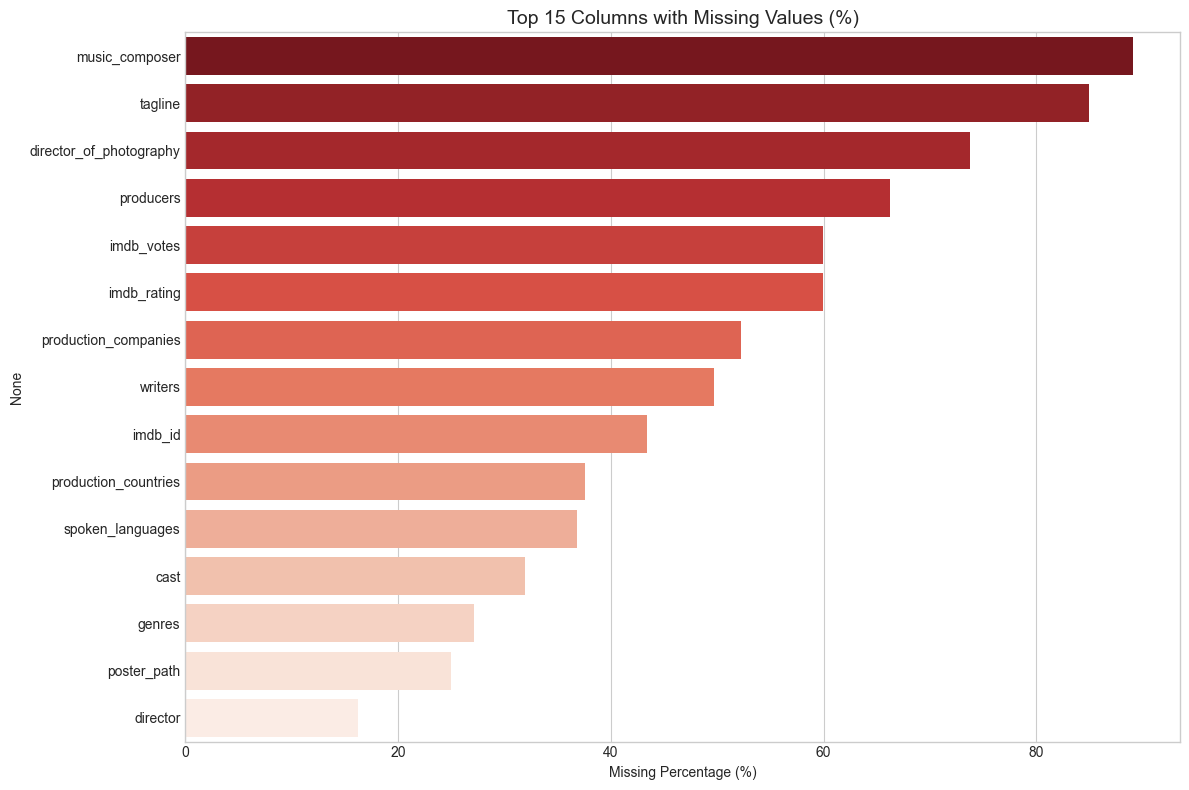

In [12]:
# Check missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
}).sort_values(by='Missing Percentage', ascending=False)

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(12, 8))
missing_cols = missing_df[missing_df['Missing Percentage'] > 0].head(15)
sns.barplot(x=missing_cols['Missing Percentage'], y=missing_cols.index, palette='Reds_r')
plt.title('Top 15 Columns with Missing Values (%)', fontsize=14)
plt.xlabel('Missing Percentage (%)')
plt.tight_layout()
plt.show()

In [13]:
# Filter dataset to keep only movies with essential information for our analysis
# We need: budget, revenue, vote_average, vote_count, genres, director, runtime

print(f"Original dataset size: {df.shape[0]}")

# Keep only released movies
df_clean = df[df['status'] == 'Released'].copy()
print(f"After filtering released movies: {df_clean.shape[0]}")

# Keep movies with budget and revenue > 0 (for meaningful financial analysis)
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)].copy()
print(f"After filtering movies with budget and revenue > 0: {df_clean.shape[0]}")

# Keep movies with valid ratings
df_clean = df_clean[(df_clean['vote_average'] > 0) & (df_clean['vote_count'] >= 10)].copy()
print(f"After filtering movies with valid ratings (vote_count >= 10): {df_clean.shape[0]}")

# Drop rows with missing essential columns
essential_cols = ['title', 'genres', 'runtime', 'original_language']
df_clean = df_clean.dropna(subset=essential_cols)
print(f"After dropping missing essential columns: {df_clean.shape[0]}")

Original dataset size: 1137484
After filtering released movies: 1118045
After filtering movies with budget and revenue > 0: 16860
After filtering movies with valid ratings (vote_count >= 10): 11159
After dropping missing essential columns: 11154
After filtering released movies: 1118045
After filtering movies with budget and revenue > 0: 16860
After filtering movies with valid ratings (vote_count >= 10): 11159
After dropping missing essential columns: 11154


### Step 2: Feature Engineering

Create new features for analysis:
- **ROI (Return on Investment)**: (Revenue - Budget) / Budget
- **Profit**: Revenue - Budget
- **Success**: Binary variable (1 if profitable, 0 otherwise)
- **Primary Genre**: Extract main genre from genre list
- **Release Year/Month**: Extract temporal features

In [14]:
# Feature Engineering

# Calculate financial metrics
df_clean['profit'] = df_clean['revenue'] - df_clean['budget']
df_clean['roi'] = (df_clean['revenue'] - df_clean['budget']) / df_clean['budget']
df_clean['success'] = (df_clean['revenue'] > df_clean['budget']).astype(int)

# Extract primary genre (first genre in the list)
def extract_primary_genre(genres_str):
    if pd.isna(genres_str):
        return 'Unknown'
    try:
        # Handle both JSON-like strings and comma-separated values
        if '[' in str(genres_str):
            import ast
            genres_list = ast.literal_eval(genres_str)
            if isinstance(genres_list, list) and len(genres_list) > 0:
                return genres_list[0].get('name', 'Unknown') if isinstance(genres_list[0], dict) else genres_list[0]
        else:
            return str(genres_str).split(',')[0].strip()
    except:
        return str(genres_str).split(',')[0].strip() if ',' in str(genres_str) else str(genres_str)
    return 'Unknown'

df_clean['primary_genre'] = df_clean['genres'].apply(extract_primary_genre)

# Extract release year and month
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_month'] = df_clean['release_date'].dt.month

# Drop rows with invalid dates
df_clean = df_clean.dropna(subset=['release_year'])
df_clean['release_year'] = df_clean['release_year'].astype(int)
df_clean['release_month'] = df_clean['release_month'].fillna(1).astype(int)

print(f"Dataset size after feature engineering: {df_clean.shape[0]}")
print(f"\nNew features created: profit, roi, success, primary_genre, release_year, release_month")
df_clean[['title', 'budget', 'revenue', 'profit', 'roi', 'success', 'primary_genre']].head(10)

Dataset size after feature engineering: 11153

New features created: profit, roi, success, primary_genre, release_year, release_month


,title,budget,revenue,profit,roi,success,primary_genre
2,Four Rooms,4000000.0,4257354.0,257354.0,0.064339,1,Comedy
3,Judgment Night,21000000.0,12136938.0,-8863062.0,-0.422051,0,Action
6,Star Wars,11000000.0,775398007.0,764398007.0,69.490728,1,Adventure
7,Finding Nemo,94000000.0,940335536.0,846335536.0,9.003570,1,Animation
8,Forrest Gump,55000000.0,677387716.0,622387716.0,11.316140,1,Comedy
9,American Beauty,15000000.0,356296601.0,341296601.0,22.753107,1,Drama
10,Citizen Kane,839727.0,23218000.0,22378273.0,26.649462,1,Mystery
11,Dancer in the Dark,12500000.0,40061153.0,27561153.0,2.204892,1,Drama
13,The Fifth Element,90000000.0,263920180.0,173920180.0,1.932446,1,Science Fiction
14,Metropolis,5300000.0,1350322.0,-3949678.0,-0.745222,0,Drama


### Step 3: Identify and Remove Outliers

Using IQR (Interquartile Range) method to detect and handle outliers in numerical features.

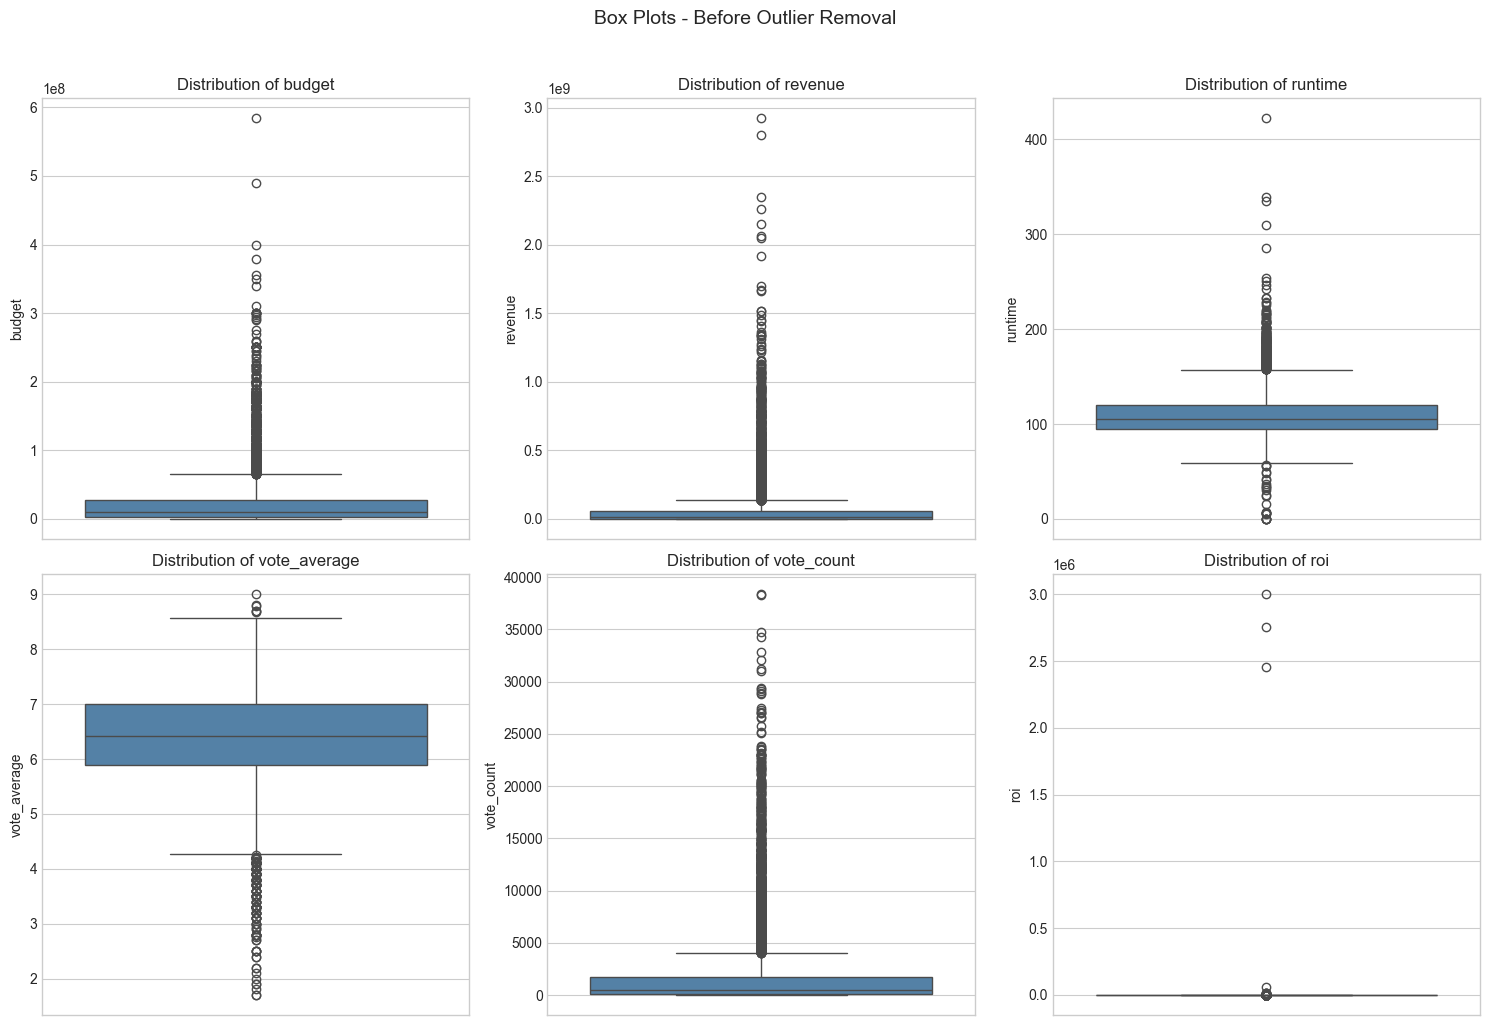


Outlier Statistics (using IQR method):
budget: 1045 outliers (9.37%)
revenue: 1407 outliers (12.62%)
runtime: 444 outliers (3.98%)
vote_average: 199 outliers (1.78%)
vote_count: 1254 outliers (11.24%)
roi: 1051 outliers (9.42%)


In [ ]:
# Visualize distribution of key numerical features before outlier removal
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numerical_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'roi']

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_clean, y=col, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel(col)

plt.suptitle('Box Plots - Before Outlier Removal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Calculate outlier statistics
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.2f}%)")

Dataset size after outlier removal: 9400


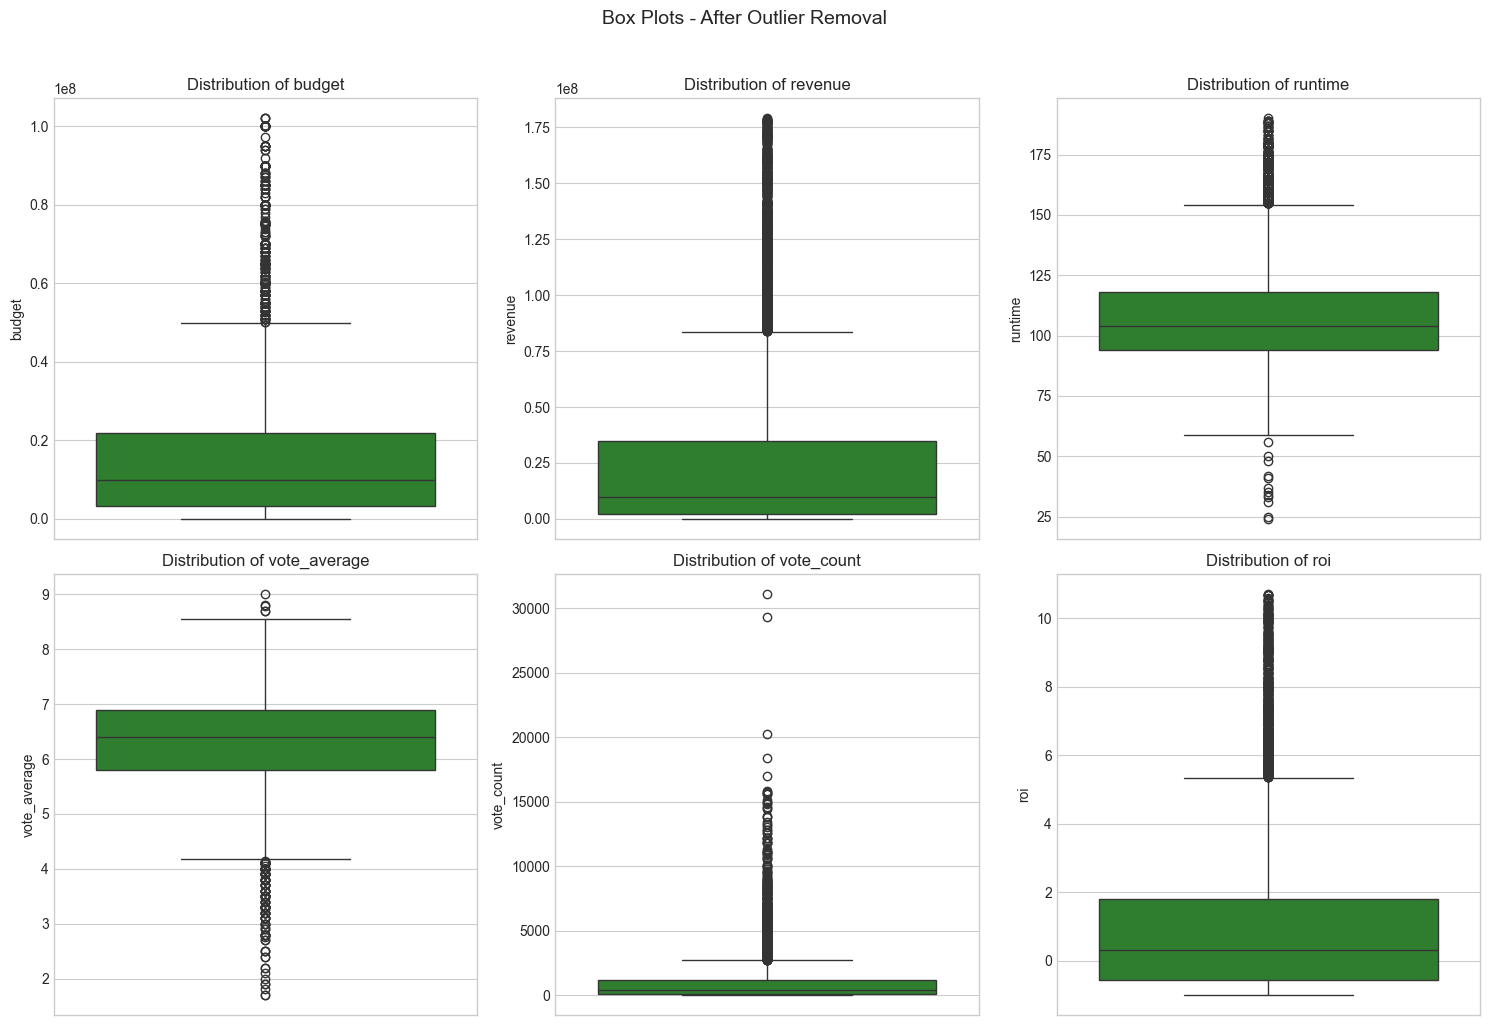

In [16]:
# Remove extreme outliers using IQR method (only for specific columns)
# We'll be conservative and only remove extreme outliers (3*IQR)

def remove_outliers_iqr(df, columns, multiplier=3):
    """Remove outliers using IQR method"""
    df_filtered = df.copy()
    for col in columns:
        Q1 = df_filtered[col].quantile(0.25)
        Q3 = df_filtered[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        df_filtered = df_filtered[(df_filtered[col] >= lower_bound) & (df_filtered[col] <= upper_bound)]
    return df_filtered

# Apply outlier removal on budget, revenue, and roi
outlier_cols = ['budget', 'revenue', 'roi', 'runtime']
df_clean = remove_outliers_iqr(df_clean, outlier_cols, multiplier=3)

print(f"Dataset size after outlier removal: {df_clean.shape[0]}")

# Visualize after outlier removal
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_clean, y=col, ax=ax, color='forestgreen')
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel(col)

plt.suptitle('Box Plots - After Outlier Removal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

Let's explore the cleaned dataset to understand patterns and relationships.

In [ ]:
# Summary statistics of cleaned data
print("Cleaned Dataset Summary:")
print(f"Total Movies: {len(df_clean)}")
print(f"Date Range: {df_clean['release_year'].min()} - {df_clean['release_year'].max()}")
print(f"Unique Genres: {df_clean['primary_genre'].nunique()}")
print(f"Unique Languages: {df_clean['original_language'].nunique()}")
print(f"\nSuccess Rate: {df_clean['success'].mean()*100:.2f}%")
print(f"Average Budget: ${df_clean['budget'].mean():,.2f}")
print(f"Average Revenue: ${df_clean['revenue'].mean():,.2f}")
print(f"Average ROI: {df_clean['roi'].mean()*100:.2f}%")

df_clean.describe().T

Cleaned Dataset Summary:
Total Movies: 9400
Date Range: 1915 - 2025
Unique Genres: 19
Unique Languages: 60

Success Rate: 57.57%
Average Budget: $16,230,062.21
Average Revenue: $26,586,388.10
Average ROI: 105.83%


,count,mean,min,25%,50%,75%,max,std
id,9400.0,177565.07383,5.0,11374.75,33995.0,259867.5,1383072.0,278681.446565
vote_average,9400.0,6.310535,1.7,5.8,6.4,6.9,9.0,0.874237
vote_count,9400.0,977.116809,10.0,102.0,380.0,1162.0,31063.0,1658.988347
release_date,9400,2001-11-21 19:03:52.851063808,1915-12-13 00:00:00,1993-12-13 12:00:00,2006-10-06 00:00:00,2014-10-22 06:00:00,2025-12-03 00:00:00,NaN
revenue,9400.0,26586388.099787,1.0,2025186.5,10000000.0,34707044.25,178866158.0,37542730.685613
runtime,9400.0,108.257447,24.0,94.0,104.0,118.0,190.0,20.308329
budget,9400.0,16230062.210957,1.0,3300000.0,10000000.0,22000000.0,102000000.0,18432601.267918
popularity,9400.0,3.793273,0.0088,1.866275,3.042,4.548125,359.3735,6.763634
imdb_rating,9398.0,6.291051,1.1,5.7,6.4,7.0,9.3,1.055874
imdb_votes,9398.0,54240.335284,18.0,5798.25,19983.5,59826.75,3128869.0,107645.027873


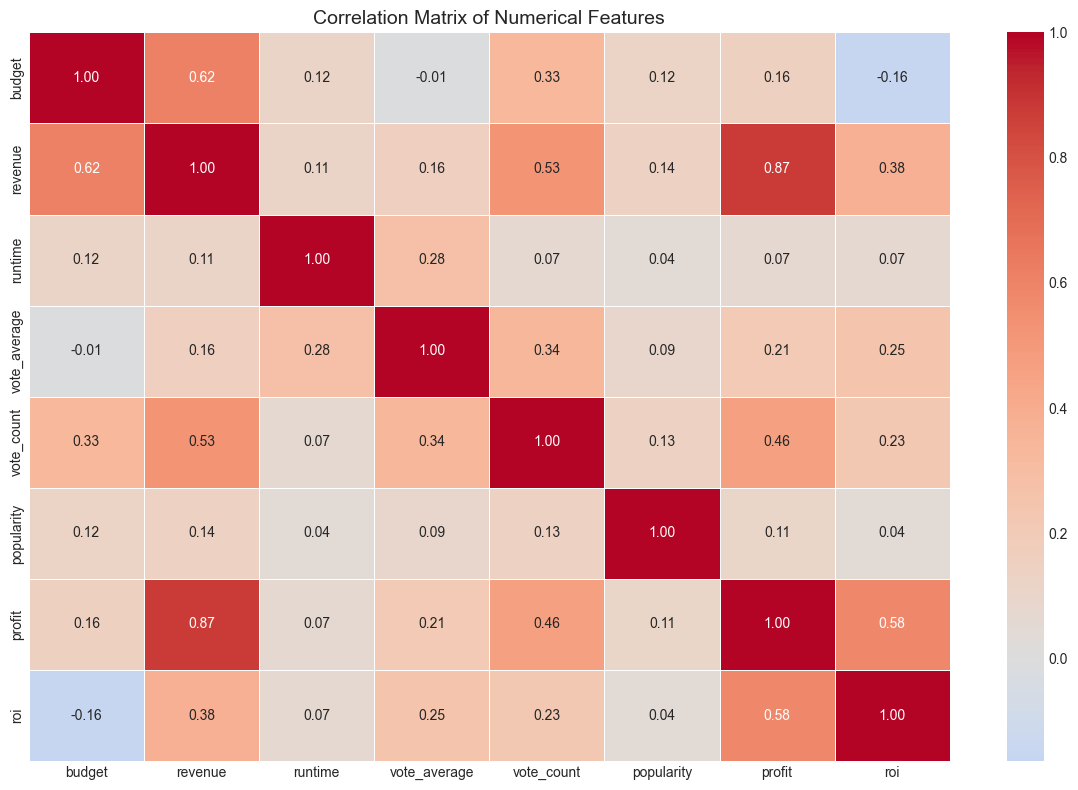

In [18]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity', 'profit', 'roi']
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

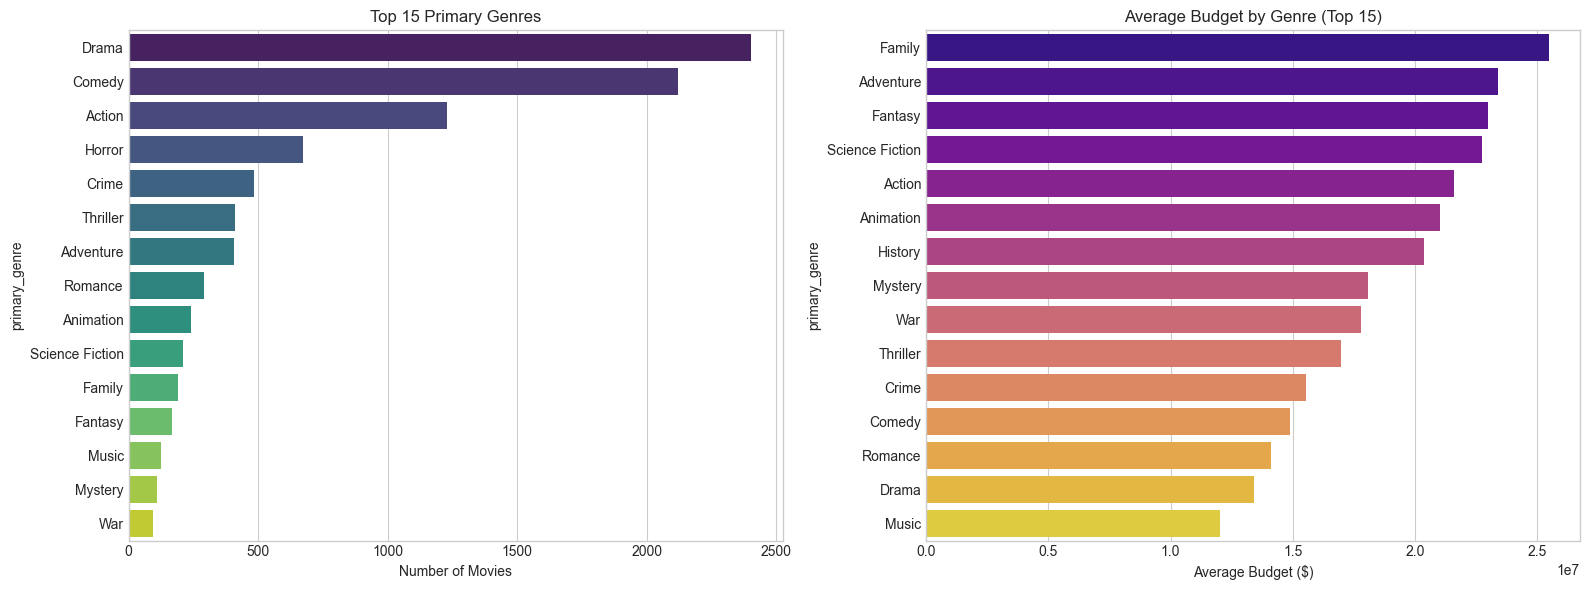

In [19]:
# Distribution of movies by genre
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Genre distribution
genre_counts = df_clean['primary_genre'].value_counts().head(15)
ax1 = axes[0]
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax1, palette='viridis')
ax1.set_title('Top 15 Primary Genres', fontsize=12)
ax1.set_xlabel('Number of Movies')

# Average budget by genre
genre_budget = df_clean.groupby('primary_genre')['budget'].mean().sort_values(ascending=False).head(15)
ax2 = axes[1]
sns.barplot(x=genre_budget.values, y=genre_budget.index, ax=ax2, palette='plasma')
ax2.set_title('Average Budget by Genre (Top 15)', fontsize=12)
ax2.set_xlabel('Average Budget ($)')

plt.tight_layout()
plt.show()

In [20]:
# Budget vs Revenue scatter plot with success coloring
fig = px.scatter(df_clean, x='budget', y='revenue', color='success',
                 hover_data=['title', 'primary_genre', 'vote_average'],
                 title='Budget vs Revenue (Success: 1=Profitable, 0=Loss)',
                 labels={'budget': 'Budget ($)', 'revenue': 'Revenue ($)', 'success': 'Profitable'},
                 color_continuous_scale='RdYlGn')
fig.add_shape(type='line', x0=0, y0=0, x1=df_clean['budget'].max(), y1=df_clean['budget'].max(),
              line=dict(color='red', dash='dash'), name='Break-even line')
fig.update_layout(height=500)
fig.show()

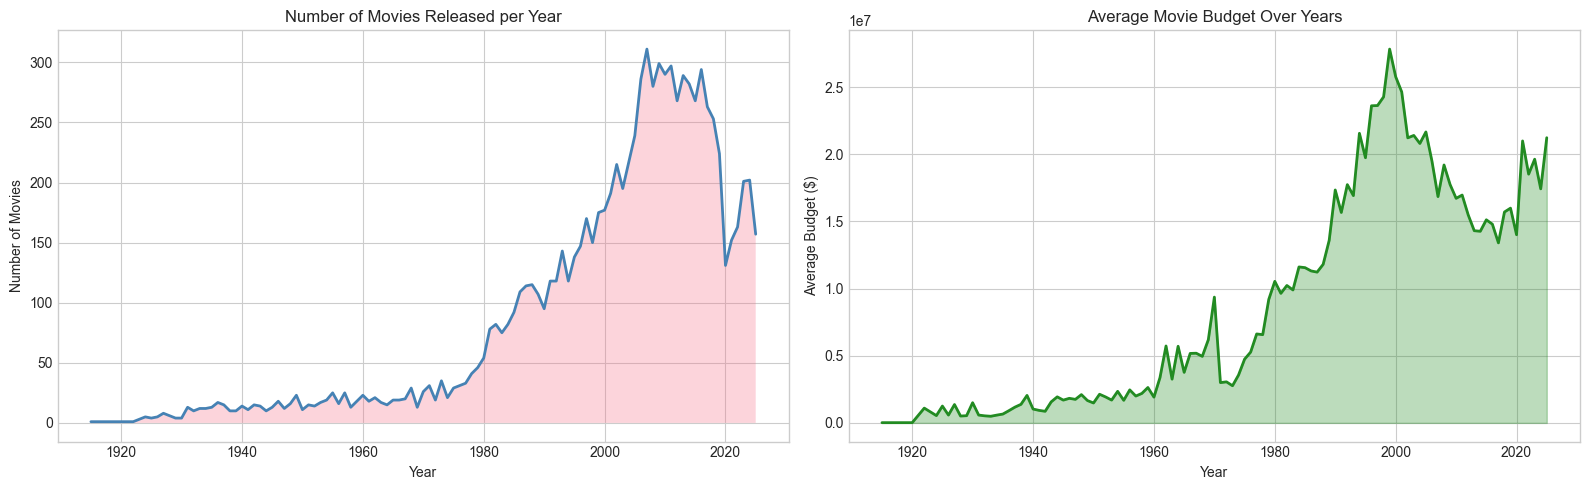

In [21]:
# Movies and Budget trends over years
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Movies per year
yearly_movies = df_clean.groupby('release_year').size()
ax1 = axes[0]
ax1.plot(yearly_movies.index, yearly_movies.values, linewidth=2, color='steelblue')
ax1.fill_between(yearly_movies.index, yearly_movies.values, alpha=0.3)
ax1.set_title('Number of Movies Released per Year', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Movies')

# Average budget over years
yearly_budget = df_clean.groupby('release_year')['budget'].mean()
ax2 = axes[1]
ax2.plot(yearly_budget.index, yearly_budget.values, linewidth=2, color='forestgreen')
ax2.fill_between(yearly_budget.index, yearly_budget.values, alpha=0.3, color='forestgreen')
ax2.set_title('Average Movie Budget Over Years', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Budget ($)')

plt.tight_layout()
plt.show()

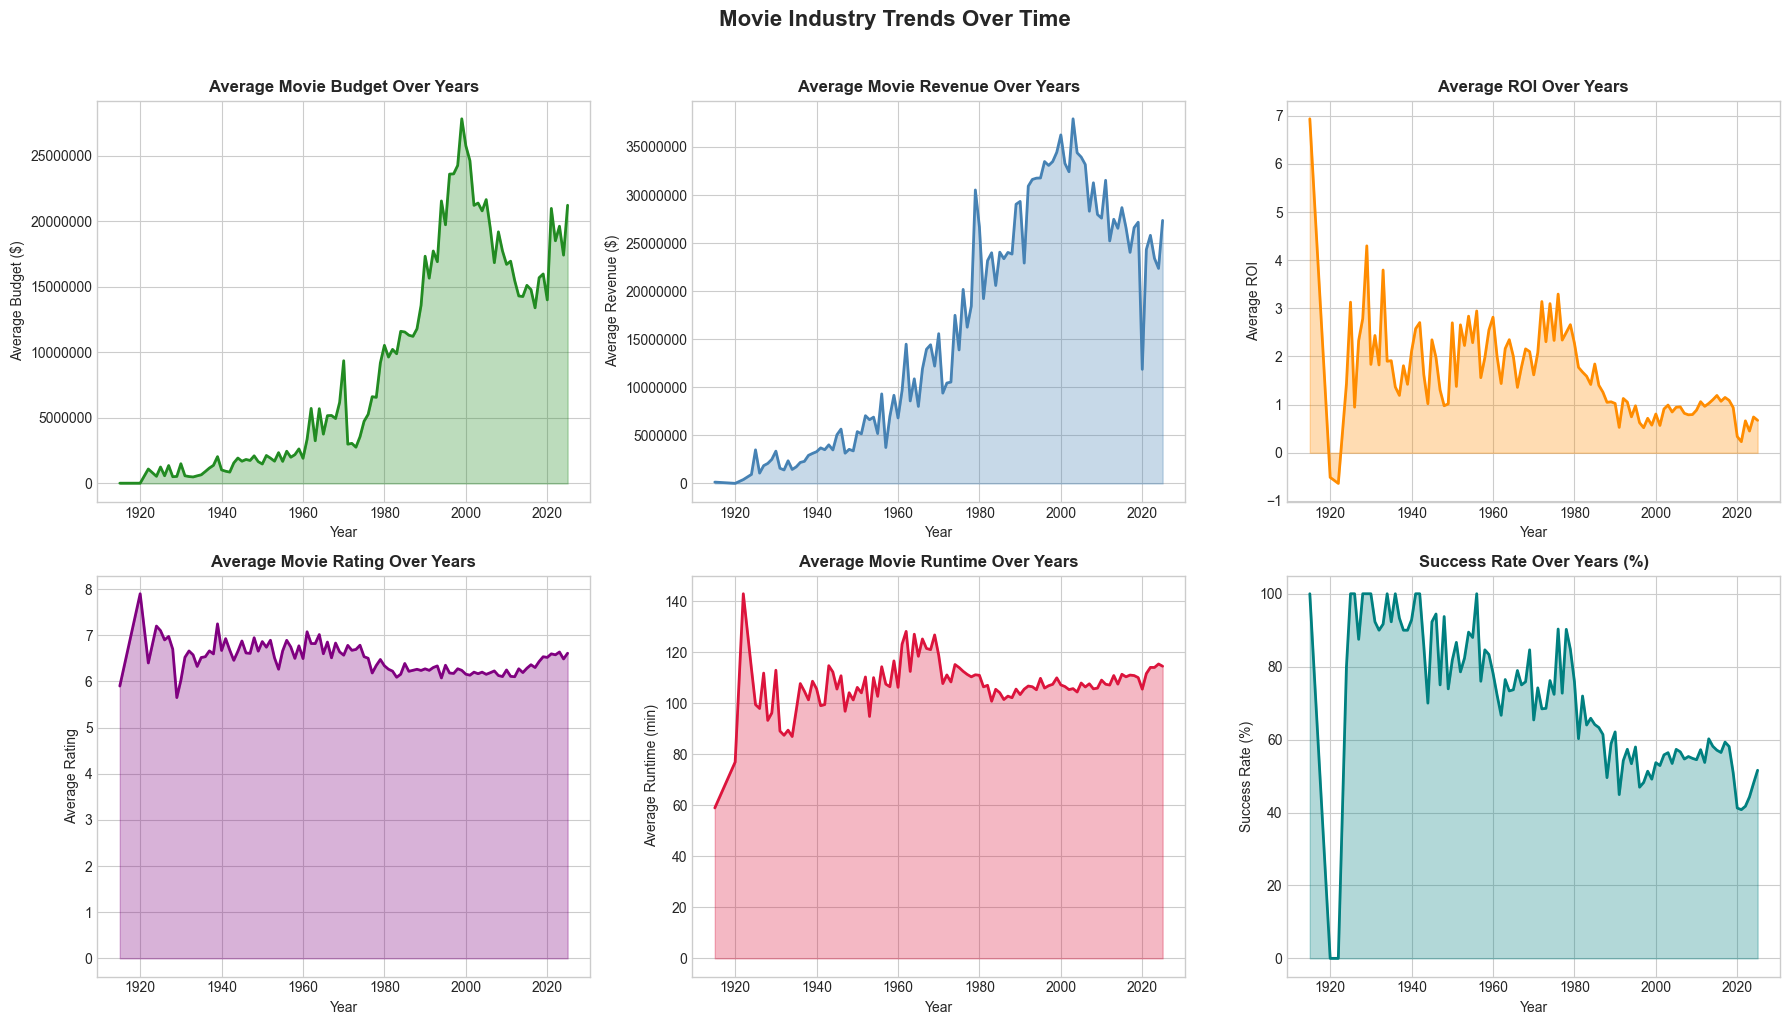

In [ ]:
# YEARLY DISTRIBUTION PLOTS FOR MULTIPLE FEATURES

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Average Budget Over Years
yearly_budget = df_clean.groupby('release_year')['budget'].mean()
axes[0, 0].plot(yearly_budget.index, yearly_budget.values, linewidth=2, color='forestgreen')
axes[0, 0].fill_between(yearly_budget.index, yearly_budget.values, alpha=0.3, color='forestgreen')
axes[0, 0].set_title('Average Movie Budget Over Years', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Average Budget ($)')
axes[0, 0].ticklabel_format(style='plain', axis='y')

# 2. Average Revenue Over Years
yearly_revenue = df_clean.groupby('release_year')['revenue'].mean()
axes[0, 1].plot(yearly_revenue.index, yearly_revenue.values, linewidth=2, color='steelblue')
axes[0, 1].fill_between(yearly_revenue.index, yearly_revenue.values, alpha=0.3, color='steelblue')
axes[0, 1].set_title('Average Movie Revenue Over Years', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average Revenue ($)')
axes[0, 1].ticklabel_format(style='plain', axis='y')

# 3. Average ROI Over Years
yearly_roi = df_clean.groupby('release_year')['roi'].mean()
axes[0, 2].plot(yearly_roi.index, yearly_roi.values, linewidth=2, color='darkorange')
axes[0, 2].fill_between(yearly_roi.index, yearly_roi.values, alpha=0.3, color='darkorange')
axes[0, 2].set_title('Average ROI Over Years', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('Average ROI')

# 4. Average Vote Average Over Years
yearly_rating = df_clean.groupby('release_year')['vote_average'].mean()
axes[1, 0].plot(yearly_rating.index, yearly_rating.values, linewidth=2, color='purple')
axes[1, 0].fill_between(yearly_rating.index, yearly_rating.values, alpha=0.3, color='purple')
axes[1, 0].set_title('Average Movie Rating Over Years', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Rating')

# 5. Average Runtime Over Years
yearly_runtime = df_clean.groupby('release_year')['runtime'].mean()
axes[1, 1].plot(yearly_runtime.index, yearly_runtime.values, linewidth=2, color='crimson')
axes[1, 1].fill_between(yearly_runtime.index, yearly_runtime.values, alpha=0.3, color='crimson')
axes[1, 1].set_title('Average Movie Runtime Over Years', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Runtime (min)')

# 6. Success Rate Over Years
yearly_success = df_clean.groupby('release_year')['success'].mean() * 100
axes[1, 2].plot(yearly_success.index, yearly_success.values, linewidth=2, color='teal')
axes[1, 2].fill_between(yearly_success.index, yearly_success.values, alpha=0.3, color='teal')
axes[1, 2].set_title('Success Rate Over Years (%)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Success Rate (%)')

plt.suptitle('Movie Industry Trends Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

K-Means Clustering Movie Market Segmentation

In [ ]:
# Prepare data for clustering
# Choose features for clustering
cluster_features = [
    'budget', 'revenue', 'profit', 'roi', 
    'vote_average', 'vote_count', 'popularity', 'runtime'
]

# Create a clean subset
df_k = df_clean.copy()
df_k = df_k.replace([np.inf, -np.inf], np.nan).dropna(subset=cluster_features).reset_index(drop=True)

print("Rows used for clustering:", len(df_k))

# Extract feature matrix
X = df_k[cluster_features].astype(float)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Rows used for clustering: 9400


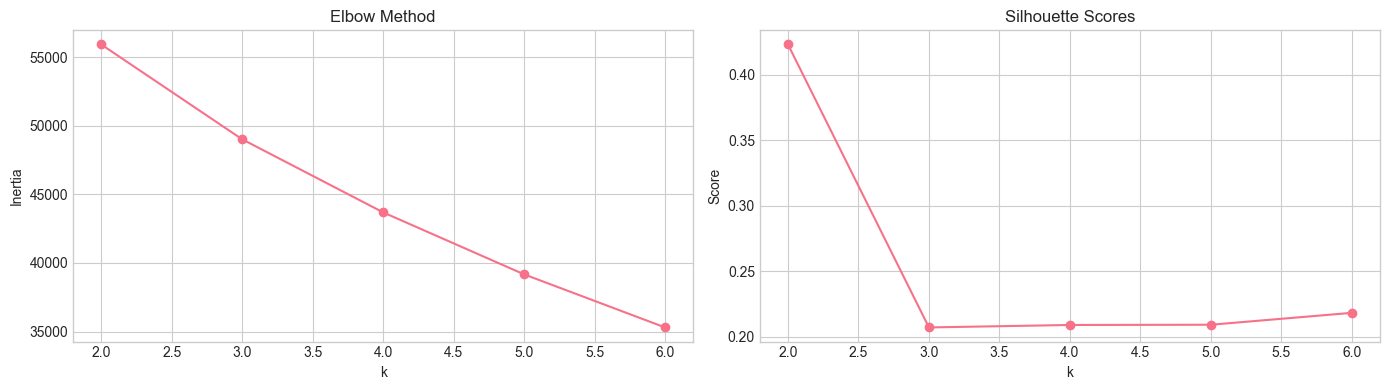

In [ ]:
# Elbow & Silhouette
inertias = []
silhouettes = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(K_range, inertias, '-o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouettes, '-o')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()


In [ ]:
# === PART 3: Fit KMeans (k=3) 

k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_k['cluster'] = kmeans.fit_predict(X_scaled)

# Centroids (scaled → original)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids, columns=cluster_features)
centroid_df['cluster'] = centroid_df.index
# Format selected columns as currency with commas, e.g. $10,385,570
cols_to_int = ['budget', 'revenue', 'profit', 'vote_count', 'runtime']

for col in cols_to_int:
    centroid_df[col] = centroid_df[col].round(0).astype(int)

# ROI, vote_average, popularity keep decimals
centroid_df['roi'] = centroid_df['roi'].round(3)
centroid_df['vote_average'] = centroid_df['vote_average'].round(2)
centroid_df['popularity'] = centroid_df['popularity'].round(3)

centroid_df
centroid_df


,budget,revenue,profit,roi,vote_average,vote_count,popularity,runtime,cluster
0,10131012,18086625,7955613,1.901,6.88,817,3.642,120,0
1,37830693,104604077,66773384,2.853,6.65,3291,6.259,111,1
2,14454582,10436758,-4017825,-0.060,5.80,432,3.198,99,2


In [ ]:
# Label clusters by performance

# Ranking clusters by ROI & Revenue
centroid_df['score'] = (
    centroid_df['roi'] * 0.6 + 
    (centroid_df['revenue'] / (centroid_df['budget']+1e-9)) * 0.4
)

centroid_df = centroid_df.sort_values('score', ascending=False).reset_index(drop=True)
centroid_df['label'] = ['Best', 'Average', 'Worst']

# Map original cluster → label
cluster_to_label = centroid_df.set_index('cluster')['label'].to_dict()

df_k['segment'] = df_k['cluster'].map(cluster_to_label)

print("Cluster → Label mapping:")
print(cluster_to_label)

centroid_df


Cluster → Label mapping:
{1: 'Best', 0: 'Average', 2: 'Worst'}


,budget,revenue,profit,roi,vote_average,vote_count,popularity,runtime,cluster,score,label
0,37830693,104604077,66773384,2.853,6.65,3291,6.259,111,1,2.817823,Best
1,10131012,18086625,7955613,1.901,6.88,817,3.642,120,0,1.854709,Average
2,14454582,10436758,-4017825,-0.060,5.80,432,3.198,99,2,0.252815,Worst


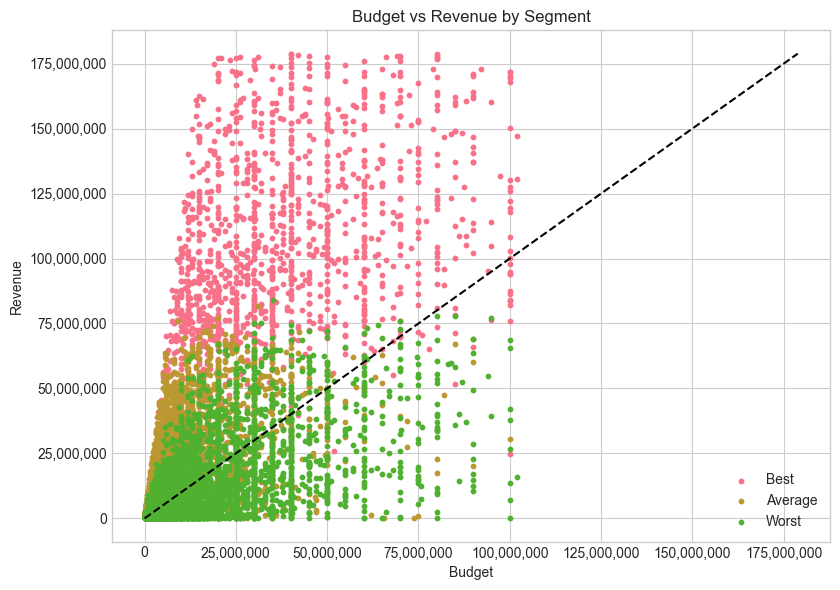

In [ ]:
# Scatter Plot (Budget vs Revenue)

plt.figure(figsize=(8,6))

for label in ['Best','Average','Worst']:
    subset = df_k[df_k['segment'] == label]
    plt.scatter(subset['budget'], subset['revenue'], s=10, label=label)

# Break-even line
max_val = max(df_k['budget'].max(), df_k['revenue'].max())
plt.plot([0, max_val], [0, max_val], 'k--')

plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue by Segment")
plt.legend()
plt.tight_layout()

# === REMOVE SCIENTIFIC NOTATION ===
plt.ticklabel_format(style='plain', axis='both')
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:,.0f}'))

plt.show()


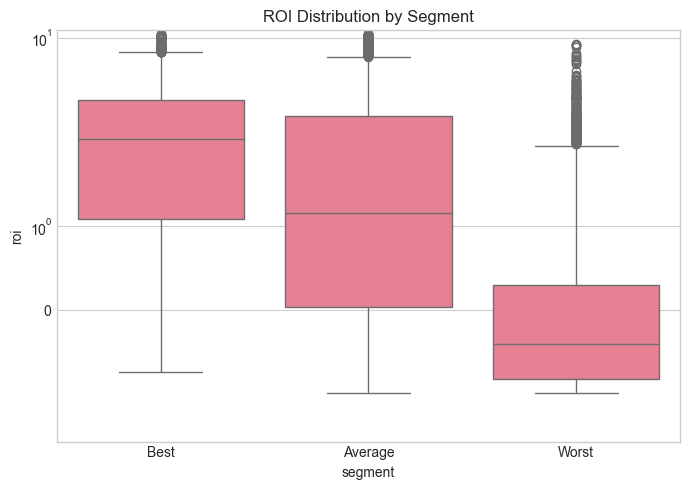

In [ ]:
# ROI Distribution

plt.figure(figsize=(7,5))
sns.boxplot(data=df_k, x='segment', y='roi', order=['Best','Average','Worst'])
plt.title("ROI Distribution by Segment")
plt.yscale('symlog')  # better visualization of extreme ROI values
plt.tight_layout()
plt.show()


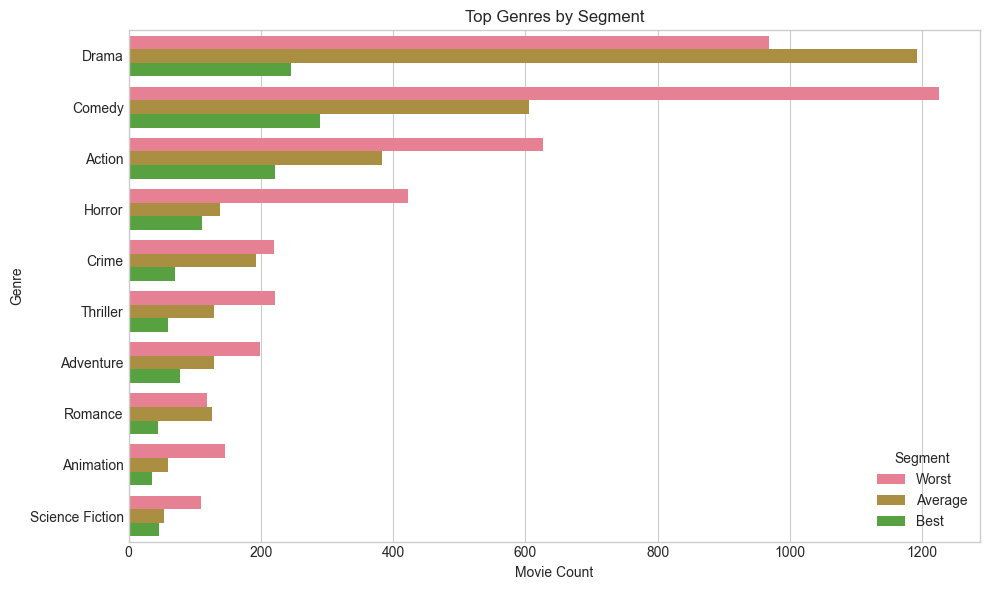

In [29]:
# Top Genres inside Clusters 

top_genres = df_k['primary_genre'].value_counts().head(10).index.tolist()

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_k[df_k['primary_genre'].isin(top_genres)],
    y='primary_genre', 
    hue='segment',
    order=top_genres
)

plt.title("Top Genres by Segment")
plt.xlabel("Movie Count")
plt.ylabel("Genre")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()


In [30]:
print("Segment Counts:")
print(df_k['segment'].value_counts())

print("\nROI Summary:")
print(df_k.groupby('segment')['roi'].agg(['count', 'mean', 'median']).round(2))

print("\nProfit Summary:")
print(df_k.groupby('segment')['profit'].agg(['count', 'mean', 'median']).round(2))


Segment Counts:
segment
Worst      4681
Average    3381
Best       1338
Name: count, dtype: int64

ROI Summary:
         count  mean  median
segment                     
Average   3381  1.90    1.16
Best      1338  2.85    2.12
Worst     4681 -0.06   -0.41

Profit Summary:
         count         mean      median
segment                                
Average   3381   7940921.78   4400000.0
Best      1338  66773384.09  64298654.5
Worst     4681  -4025118.80  -2056523.0


In [ ]:
# ============================================================
# SAVE K-MEANS MODEL AND METADATA FOR STREAMLIT
# ============================================================

import pickle
import os

# Create models directory if not exists
os.makedirs('models', exist_ok=True)

# Save the KMeans model
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save the scaler
with open('models/kmeans_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata for Streamlit
kmeans_metadata = {
    'cluster_features': cluster_features,
    'n_clusters': k_final,
    'cluster_labels': cluster_to_label,
    'centroids': centroid_df.to_dict('records'),
    'silhouette_scores': dict(zip(K_range, silhouettes)),
    'inertias': dict(zip(K_range, inertias)),
    'segment_stats': {
        'counts': df_k['segment'].value_counts().to_dict(),
        'roi_mean': df_k.groupby('segment')['roi'].mean().to_dict(),
        'profit_mean': df_k.groupby('segment')['profit'].mean().to_dict()
    }
}

with open('models/kmeans_metadata.pkl', 'wb') as f:
    pickle.dump(kmeans_metadata, f)

print(" K-Means model and metadata saved successfully!")
print(f"   - models/kmeans_model.pkl")
print(f"   - models/kmeans_scaler.pkl")
print(f"   - models/kmeans_metadata.pkl")

✅ K-Means model and metadata saved successfully!
   - models/kmeans_model.pkl
   - models/kmeans_scaler.pkl
   - models/kmeans_metadata.pkl
